<a href="https://colab.research.google.com/github/jcmachicao/cur_MMAI__multimodal/blob/main/cur_IAMM___RAG_Cognitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import pandas as pd

### Configuración del modelo de Embedding y Generación de Embeddings

Primero, configuraremos la API de Gemini para usar un modelo de embedding y luego generaremos los vectores de embedding para la columna 'contenido' de `df_corpus_textos`.

In [ ]:
print("Listando modelos de embedding disponibles:")
for m in genai.list_models():
    if "embedContent" in m.supported_generation_methods:
        print(m.name)

Listando modelos de embedding disponibles:


NameError: name 'genai' is not defined

In [ ]:
ruta = "drive/My Drive/2026 Cursos/lab_RAG_cognitivo_data/"
os.listdir(ruta)

['caso_policial_modelo_base_vlab.json', 'caso_policial_corpus_textos.json']

In [ ]:
file_path_corpus_textos = os.path.join(ruta, 'caso_policial_corpus_textos.json')
df_corpus_textos = pd.read_json(file_path_corpus_textos)
print("\nDataFrame 'df_corpus_textos' cargado. Primeras 5 filas:")
display(df_corpus_textos.head())
print(f"Filas cargadas en df_corpus_textos: {len(df_corpus_textos)}")
if 'texto' in df_corpus_textos.columns:
    print(f"Tipo de datos de la columna 'texto': {df_corpus_textos['texto'].dtype}")


DataFrame 'df_corpus_textos' cargado. Primeras 5 filas:


,id,tipo,titulo,texto
0,DOC01,informe_inicial,Informe inicial del incidente,El 14 de mayo de 2026 se reportó la ausencia d...
1,DOC02,declaracion,Declaración de Carlos Mendoza,Carlos Mendoza declaró que ingresó al Almacén ...
2,DOC03,declaracion,Declaración de Maria Torres,Maria Torres declaró que inició su turno a las...
3,DOC04,declaracion,Declaración de Luis Ramirez,"Luis Ramirez, técnico de mantenimiento, declar..."
4,DOC05,declaracion,Declaración de Ana Flores,Ana Flores declaró que ingresó al estacionamie...


Filas cargadas en df_corpus_textos: 12
Tipo de datos de la columna 'texto': object


In [ ]:
for tx in df_corpus_textos.texto:
  print(tx)

El 14 de mayo de 2026 se reportó la ausencia de la Caja 17 en el Almacén Central de Distribución. La supervisora de turno, Maria Torres, detectó el faltante aproximadamente a las 21:40, durante una revisión de la zona de despacho. La caja contenía equipos electrónicos y se encontraba originalmente en dicha zona. Los primeros registros revisados indican que Carlos Mendoza ingresó al almacén a las 20:42 y que una camioneta de Transportes Norte ingresó por la puerta lateral a las 20:55. Posteriormente se identificó un movimiento de la Caja 17 a las 21:18 y una apertura de la puerta lateral a las 21:19.
Carlos Mendoza declaró que ingresó al Almacén Central aproximadamente a las 20:40 para cumplir sus funciones habituales. Señaló que durante el turno permaneció principalmente dentro de las instalaciones y que no participó en ningún movimiento irregular de mercancía. Según su declaración, estuvo dentro del almacén hasta aproximadamente las 22:00. Carlos indicó que conocía la ubicación de la 

In [ ]:
import google.generativeai as genai
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOO_AK')
genai.configure(api_key=GOOGLE_API_KEY) # Configura la API key globalmente
embedding_model = 'models/gemini-embedding-001' # Actualizado a un modelo disponible
print(f"Modelo de embedding cargado: {embedding_model}")

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Modelo de embedding cargado: models/gemini-embedding-001


In [ ]:
print(f"Filas en df_corpus_textos antes de generar embeddings: {len(df_corpus_textos)}")

def get_embedding(text):
    if not isinstance(text, str) or not text.strip():
        print(f"Advertencia: Texto inválido o vacío. Tipo: {type(text)}, Contenido: {str(text)[:50]}...")
        return None
    try:
        # Usar genai.embed_content directamente, ya que la API key está configurada globalmente
        response = genai.embed_content(model=embedding_model, content=text)
        if 'embedding' in response:
            return response['embedding']
        else:
            print(f"Error: 'embedding' no encontrado en la respuesta para el texto: {str(text)[:50]}... Respuesta: {response}")
            return None
    except Exception as e:
        print(f"Error al generar embedding para el texto: {str(text)[:50]}... Error: {e}")
        return None

# Aplicar la función de embedding a la columna 'texto'
df_corpus_textos['embedding'] = df_corpus_textos['texto'].apply(get_embedding)

# Eliminar filas donde el embedding falló (si las hay)
df_corpus_textos.dropna(subset=['embedding'], inplace=True)

print(f"Embeddings generados para {len(df_corpus_textos)} textos.")
display(df_corpus_textos.head())

Filas en df_corpus_textos antes de generar embeddings: 12
Embeddings generados para 12 textos.


,id,tipo,titulo,texto,embedding
0,DOC01,informe_inicial,Informe inicial del incidente,El 14 de mayo de 2026 se reportó la ausencia d...,"[-0.0062278016, -0.004653262, 0.009707253, -0...."
1,DOC02,declaracion,Declaración de Carlos Mendoza,Carlos Mendoza declaró que ingresó al Almacén ...,"[-0.0040936135, 0.00030420595, 0.0025292665, -..."
2,DOC03,declaracion,Declaración de Maria Torres,Maria Torres declaró que inició su turno a las...,"[-0.009011569, 0.00038905698, -0.0066740094, -..."
3,DOC04,declaracion,Declaración de Luis Ramirez,"Luis Ramirez, técnico de mantenimiento, declar...","[0.0030613774, 0.010979461, -0.0048105456, -0...."
4,DOC05,declaracion,Declaración de Ana Flores,Ana Flores declaró que ingresó al estacionamie...,"[-0.027838001, 0.013974956, -0.0019958753, -0...."


### Reducción de Dimensionalidad (PCA) y Visualización

Ahora, utilizaremos PCA (Análisis de Componentes Principales) para reducir los embeddings a 2 dimensiones y luego los visualizaremos en un gráfico de dispersión.

### Función de Visualización de Embeddings

Aquí se define una función para visualizar los embeddings 2D, que permite mayor flexibilidad, como añadir etiquetas a los puntos.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_embeddings_2d(
    df: pd.DataFrame,
    embedding_col: str = 'embedding',
    hue_col: str = 'tipo',
    label_col: str = None,
    title: str = 'Proyección 2D de Embeddings de Textos (PCA)',
    palette: str = 'viridis'
):
    """
    Visualiza los embeddings de un DataFrame en 2D usando PCA.

    Args:
        df (pd.DataFrame): DataFrame que contiene los embeddings.
        embedding_col (str): Nombre de la columna que contiene los embeddings.
        hue_col (str): Nombre de la columna a usar para colorear los puntos.
        label_col (str, opcional): Nombre de la columna a usar para etiquetar los puntos. Por defecto es None.
        title (str): Título del gráfico.
        palette (str): Paleta de colores para el gráfico de dispersión.
    """

    # Asegurarse de que las columnas PCA estén presentes o generarlas
    if 'pca_x' not in df.columns or 'pca_y' not in df.columns:
        print("Generando componentes PCA...")
        embeddings_array = np.array(df[embedding_col].tolist())
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings_array)
        df['pca_x'] = embeddings_2d[:, 0]
        df['pca_y'] = embeddings_2d[:, 1]

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='pca_x',
        y='pca_y',
        hue=hue_col,
        data=df,
        palette=palette,
        s=100,
        alpha=0.7
    )

    if label_col:
        for i, row in df.iterrows():
            plt.text(row['pca_x'] + 0.01, row['pca_y'] + 0.01, row[label_col], fontsize=9)

    plt.title(title)
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

### Visualización de Embeddings con la Nueva Función

Ahora usamos la función `plot_embeddings_2d` para generar el gráfico.

Generando componentes PCA...


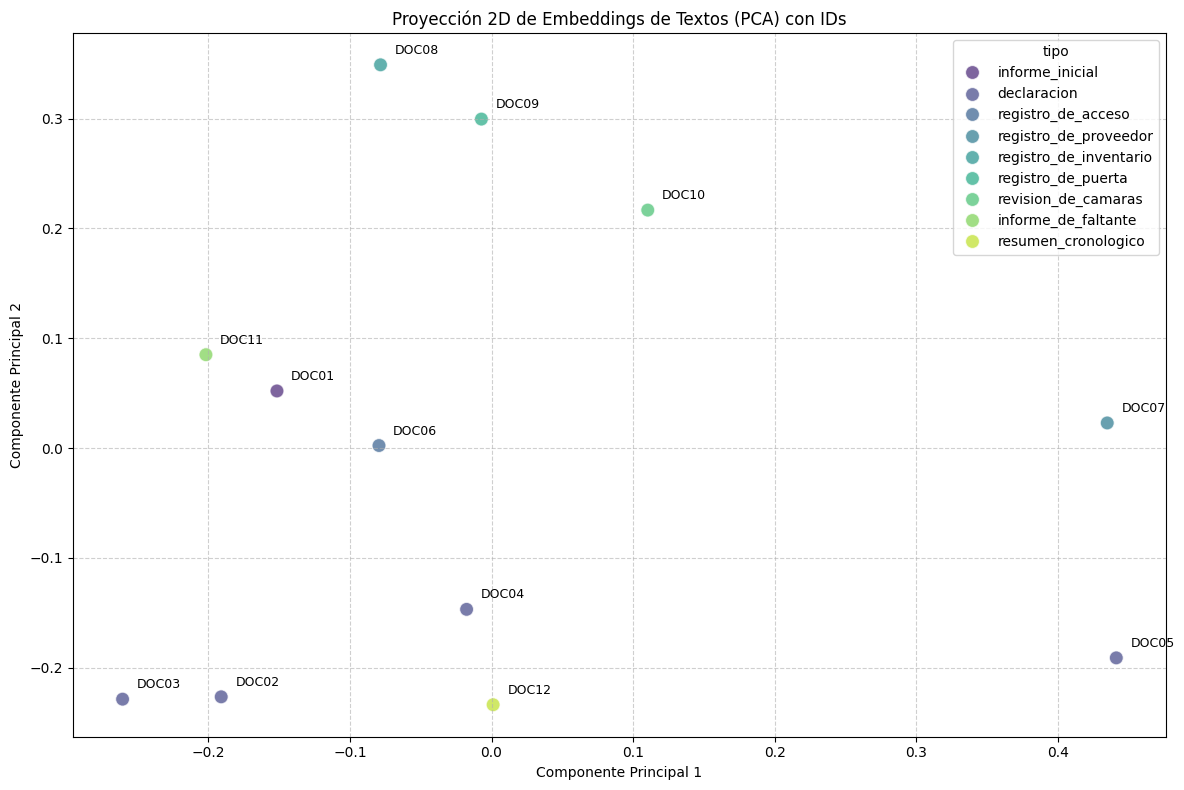

In [ ]:
plot_embeddings_2d(
    df=df_corpus_textos,
    hue_col='tipo', # Colorear por el tipo de documento
    label_col='id', # Etiquetar cada punto con su ID de documento
    title='Proyección 2D de Embeddings de Textos (PCA) con IDs'
)

### Preparación para la División de Textos en Pares de Oraciones

Aquí importaremos `nltk` y descargaremos el tokenizador necesario, si aún no está disponible.

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    # Para sent_tokenize(language='spanish'), se necesita 'punkt_tab'
    nltk.data.find('tokenizers/punkt_tab/spanish/')
except LookupError:
    nltk.download('punkt_tab')

print("NLTK y los tokenizadores 'punkt' y 'punkt_tab' están listos.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK y los tokenizadores 'punkt' y 'punkt_tab' están listos.


### Función para Generar Pares de Oraciones

Esta función tomará un texto y lo dividirá en oraciones, luego generará pares consecutivos de estas oraciones.

In [ ]:
def generate_sentence_pairs(text, doc_id, doc_tipo, doc_titulo):
    sentences = sent_tokenize(text, language='spanish')
    pairs = []
    for i in range(len(sentences) - 1):
        pair_text = sentences[i] + ' ' + sentences[i+1]
        pairs.append({
            'doc_id': doc_id,
            'doc_tipo': doc_tipo,
            'doc_titulo': doc_titulo,
            'pair_index': i,
            'texto_par': pair_text
        })
    return pairs

print("Función 'generate_sentence_pairs' definida.")

Función 'generate_sentence_pairs' definida.


### Aplicar la Función y Crear Nuevo DataFrame de Pares

Ahora aplicaremos la función a `df_corpus_textos` para crear un nuevo DataFrame `df_pares_oraciones`.

In [ ]:
all_sentence_pairs = []
for index, row in df_corpus_textos.iterrows():
    pairs = generate_sentence_pairs(row['texto'], row['id'], row['tipo'], row['titulo'])
    all_sentence_pairs.extend(pairs)

df_pares_oraciones = pd.DataFrame(all_sentence_pairs)

print(f"Se generaron {len(df_pares_oraciones)} pares de oraciones.")
print("Primeras 5 filas del nuevo DataFrame 'df_pares_oraciones':")
display(df_pares_oraciones.head())

Se generaron 46 pares de oraciones.
Primeras 5 filas del nuevo DataFrame 'df_pares_oraciones':


,doc_id,doc_tipo,doc_titulo,pair_index,texto_par
0,DOC01,informe_inicial,Informe inicial del incidente,0,El 14 de mayo de 2026 se reportó la ausencia d...
1,DOC01,informe_inicial,Informe inicial del incidente,1,"La supervisora de turno, Maria Torres, detectó..."
2,DOC01,informe_inicial,Informe inicial del incidente,2,La caja contenía equipos electrónicos y se enc...
3,DOC01,informe_inicial,Informe inicial del incidente,3,Los primeros registros revisados indican que C...
4,DOC02,declaracion,Declaración de Carlos Mendoza,0,Carlos Mendoza declaró que ingresó al Almacén ...


### Generar Embeddings para los Pares de Oraciones

Ahora aplicaremos la función `get_embedding` a la columna `texto_par` del nuevo DataFrame.

In [ ]:
print(f"Filas en df_pares_oraciones antes de generar embeddings: {len(df_pares_oraciones)}")

df_pares_oraciones['embedding'] = df_pares_oraciones['texto_par'].apply(get_embedding)
df_pares_oraciones.dropna(subset=['embedding'], inplace=True)

print(f"Embeddings generados para {len(df_pares_oraciones)} pares de oraciones.")
display(df_pares_oraciones.head())

Filas en df_pares_oraciones antes de generar embeddings: 46
Embeddings generados para 46 pares de oraciones.


,doc_id,doc_tipo,doc_titulo,pair_index,texto_par,embedding
0,DOC01,informe_inicial,Informe inicial del incidente,0,El 14 de mayo de 2026 se reportó la ausencia d...,"[-0.009427701, 0.0071213283, 0.0044334168, -0...."
1,DOC01,informe_inicial,Informe inicial del incidente,1,"La supervisora de turno, Maria Torres, detectó...","[-0.0014527332, -0.0022908773, -0.007972724, -..."
2,DOC01,informe_inicial,Informe inicial del incidente,2,La caja contenía equipos electrónicos y se enc...,"[-0.006925503, -0.015919339, 0.0063049034, -0...."
3,DOC01,informe_inicial,Informe inicial del incidente,3,Los primeros registros revisados indican que C...,"[-0.014385913, -0.0017066116, 0.0052286, -0.02..."
4,DOC02,declaracion,Declaración de Carlos Mendoza,0,Carlos Mendoza declaró que ingresó al Almacén ...,"[-0.0016078699, 0.0071693286, 0.004773532, -0...."


In [ ]:
df_pares_oraciones["label"] = df_pares_oraciones["doc_id"].astype(str) + "-" + df_pares_oraciones["pair_index"].astype(str)
df_pares_oraciones.head()

,doc_id,doc_tipo,doc_titulo,pair_index,texto_par,embedding,label
0,DOC01,informe_inicial,Informe inicial del incidente,0,El 14 de mayo de 2026 se reportó la ausencia d...,"[-0.009427701, 0.0071213283, 0.0044334168, -0....",DOC01-0
1,DOC01,informe_inicial,Informe inicial del incidente,1,"La supervisora de turno, Maria Torres, detectó...","[-0.0014527332, -0.0022908773, -0.007972724, -...",DOC01-1
2,DOC01,informe_inicial,Informe inicial del incidente,2,La caja contenía equipos electrónicos y se enc...,"[-0.006925503, -0.015919339, 0.0063049034, -0....",DOC01-2
3,DOC01,informe_inicial,Informe inicial del incidente,3,Los primeros registros revisados indican que C...,"[-0.014385913, -0.0017066116, 0.0052286, -0.02...",DOC01-3
4,DOC02,declaracion,Declaración de Carlos Mendoza,0,Carlos Mendoza declaró que ingresó al Almacén ...,"[-0.0016078699, 0.0071693286, 0.004773532, -0....",DOC02-0


### Visualizar Embeddings de los Pares de Oraciones

Finalmente, usaremos la función `plot_embeddings_2d` para visualizar los embeddings de los pares de oraciones.

Generando componentes PCA...


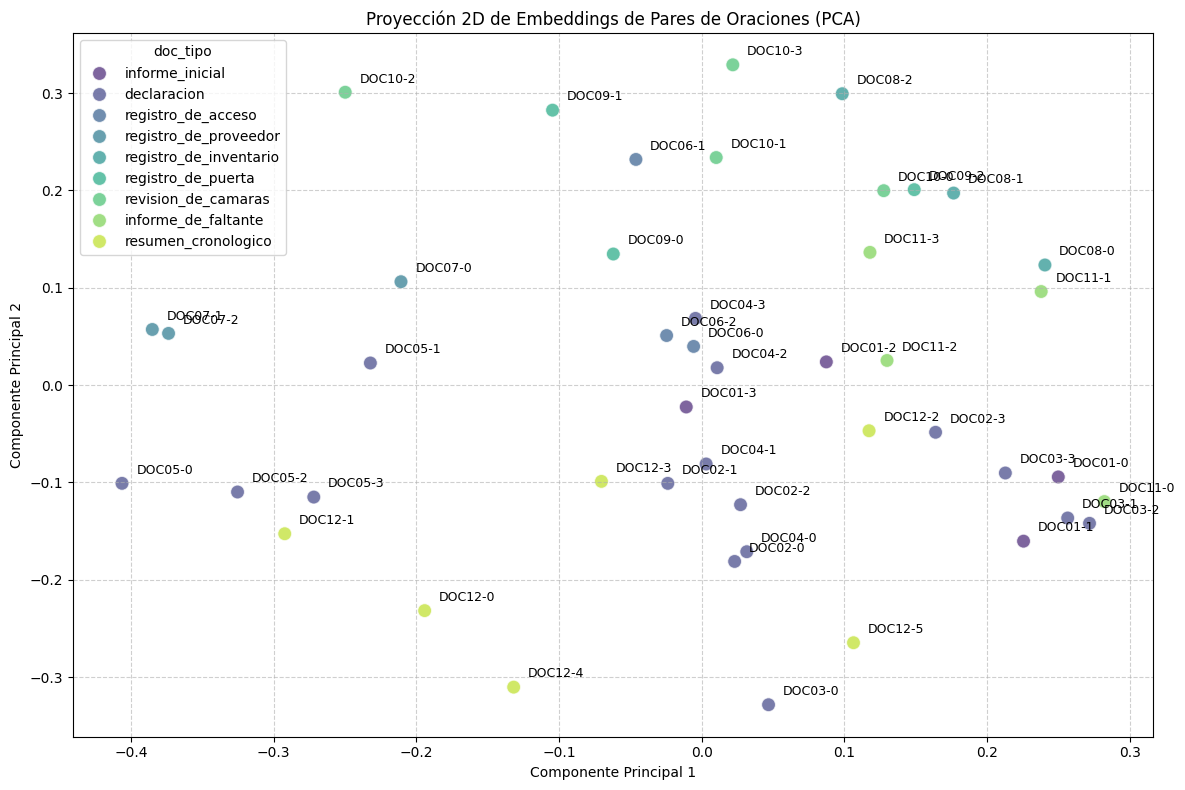

In [ ]:
plot_embeddings_2d(
    df=df_pares_oraciones,
    hue_col='doc_tipo', # Colorear por el tipo de documento original
    label_col='label', # Quitar etiquetas para evitar sobrecargar el gráfico
    title='Proyección 2D de Embeddings de Pares de Oraciones (PCA)',
    embedding_col='embedding'
)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

# Convertir los embeddings a un array NumPy
embeddings_array = np.array(df_pares_oraciones['embedding'].tolist())

# Aplicar KMeans para agrupar los pares de oraciones
# Elegimos un número de clusters (por ejemplo, 5) para empezar
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar warnings
df_pares_oraciones['cluster'] = kmeans.fit_predict(embeddings_array)

print(f"Clusters generados para {len(df_pares_oraciones)} pares de oraciones.")
print("Distribución de pares de oraciones por cluster:")
display(df_pares_oraciones['cluster'].value_counts())

# Seleccionar dos clusters para comparar (puedes ajustar estos IDs)
# Intentar seleccionar clusters que tengan al menos 5 elementos para la comparación
cluster_counts = df_pares_oraciones['cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts >= 5].index.tolist()

if len(valid_clusters) < 2:
    print("No hay suficientes clusters con al menos 5 elementos para comparar dos. Ajustando el número de clusters (k) o la cantidad mínima de elementos.")
    # Fallback si no hay suficientes clusters grandes
    # Aquí podríamos reintentar con menos k o elegir los clusters más grandes disponibles
    # Por simplicidad para este ejemplo, si no hay 2 validos, tomamos los 2 más grandes disponibles si existen
    if len(cluster_counts) >= 2:
        selected_cluster_ids = cluster_counts.nlargest(2).index.tolist()
    else:
        print("No se pueden seleccionar 2 clusters para comparar.")
        selected_cluster_ids = []
else:
    selected_cluster_ids = valid_clusters[:2] # Tomar los dos primeros clusters válidos

if selected_cluster_ids:
    print(f"Comparando clusters con IDs: {selected_cluster_ids[0]} y {selected_cluster_ids[1]}")

    for cluster_id in selected_cluster_ids:
        print(f"\n--- Cluster {cluster_id} ---")
        # Obtener los pares de oraciones de este cluster
        cluster_df = df_pares_oraciones[df_pares_oraciones['cluster'] == cluster_id].copy()

        # Calcular distancias al centroide del cluster
        centroid = kmeans.cluster_centers_[cluster_id]
        distances = euclidean_distances(cluster_df['embedding'].tolist(), centroid.reshape(1, -1))
        cluster_df['distance_to_centroid'] = distances

        # Seleccionar los 5 pares de oraciones más cercanos al centroide
        closest_pairs = cluster_df.sort_values(by='distance_to_centroid').head(5)

        for idx, row in closest_pairs.iterrows():
            print(f"  Label: {row['label']} (Doc Tipo: {row['doc_tipo']})")
            print(f"  Texto: {row['texto_par']}")
            print("  ---")
else:
    print("No se pudieron identificar clusters válidos para la comparación.")

Clusters generados para 46 pares de oraciones.
Distribución de pares de oraciones por cluster:


,count
cluster,
3,11
0,11
2,9
1,9
4,6


Comparando clusters con IDs: 3 y 0

--- Cluster 3 ---
  Label: DOC11-0 (Doc Tipo: informe_de_faltante)
  Texto: Durante la revisión realizada aproximadamente a las 21:40, Maria Torres detectó que la Caja 17 ya no se encontraba en la zona de despacho. La caja correspondía a un lote de equipos electrónicos registrado en el inventario del almacén.
  ---
  Label: DOC01-1 (Doc Tipo: informe_inicial)
  Texto: La supervisora de turno, Maria Torres, detectó el faltante aproximadamente a las 21:40, durante una revisión de la zona de despacho. La caja contenía equipos electrónicos y se encontraba originalmente en dicha zona.
  ---
  Label: DOC03-2 (Doc Tipo: declaracion)
  Texto: Aproximadamente a las 21:40 observó que la Caja 17 ya no se encontraba en el lugar donde había sido almacenada. Maria señaló que en ese momento no había autorizado ninguna salida de esa caja.
  ---
  Label: DOC12-5 (Doc Tipo: resumen_cronologico)
  Texto: A las 21:40 Maria detectó el faltante y a las 21:50 revisó los re

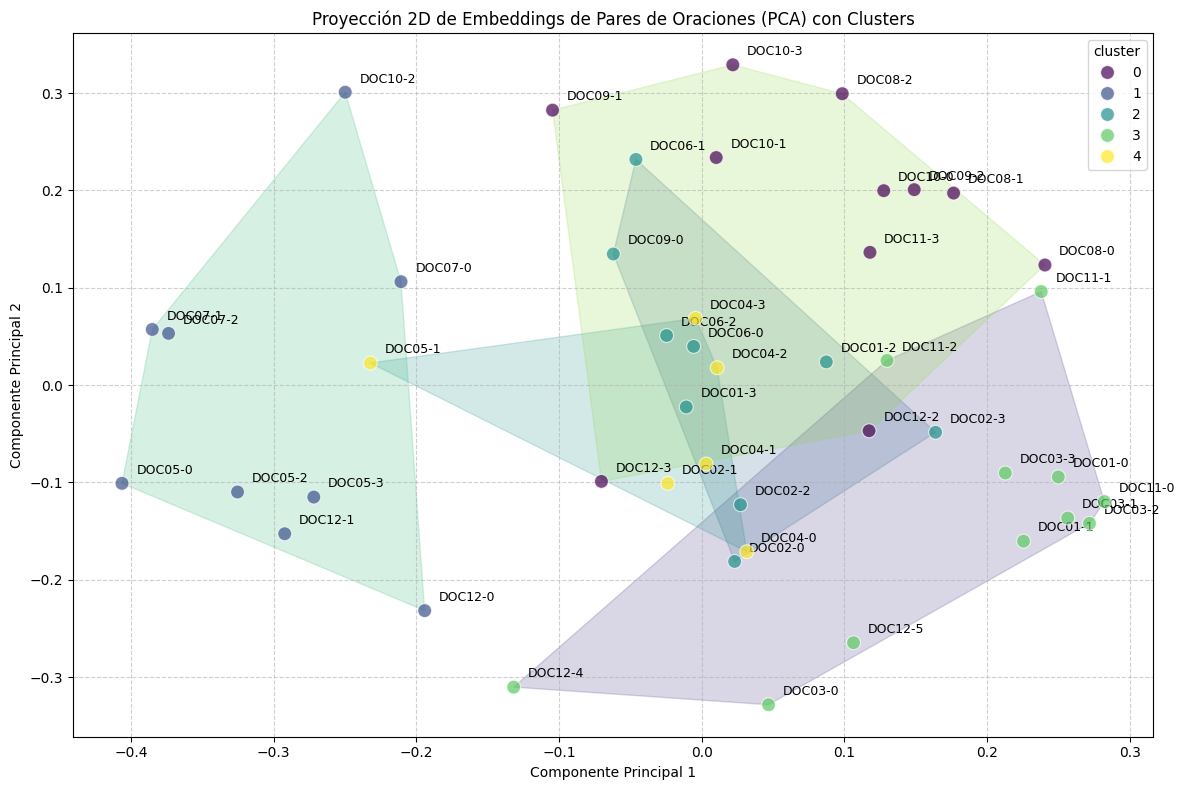

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull

def plot_embeddings_2d(
    df: pd.DataFrame,
    embedding_col: str = 'embedding',
    hue_col: str = None,
    label_col: str = None,
    cluster_col: str = None, # Nuevo parámetro para la columna de clusters
    title: str = 'Proyección 2D de Embeddings (PCA)',
    palette: str = 'viridis',
    show_convex_hull: bool = True # Controla si se dibuja el convex hull
):
    """
    Visualiza los embeddings de un DataFrame en 2D usando PCA, con opción de clusters y convex hull.

    Args:
        df (pd.DataFrame): DataFrame que contiene los embeddings.
        embedding_col (str): Nombre de la columna que contiene los embeddings.
        hue_col (str, opcional): Nombre de la columna a usar para colorear los puntos. Por defecto es None.
        label_col (str, opcional): Nombre de la columna a usar para etiquetar los puntos. Por defecto es None.
        cluster_col (str, opcional): Nombre de la columna que contiene los IDs de cluster. Si se proporciona, se intentará dibujar convex hulls.
        title (str): Título del gráfico.
        palette (str): Paleta de colores para el gráfico de dispersión.
        show_convex_hull (bool): Si es True y `cluster_col` está presente, dibuja los convex hulls para los clusters.
    """

    # Asegurarse de que las columnas PCA estén presentes o generarlas
    if 'pca_x' not in df.columns or 'pca_y' not in df.columns:
        print("Generando componentes PCA...")
        embeddings_array = np.array(df[embedding_col].tolist())
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings_array)
        df['pca_x'] = embeddings_2d[:, 0]
        df['pca_y'] = embeddings_2d[:, 1]

    plt.figure(figsize=(12, 8))

    # Convertir paleta a un diccionario si es una cadena
    if isinstance(palette, str):
        if hue_col and len(df[hue_col].unique()) <= 10: # Limitar para evitar paletas demasiado grandes
            current_palette = sns.color_palette(palette, n_colors=len(df[hue_col].unique()))
        else:
            current_palette = sns.color_palette(palette)
        palette_dict = {k: v for k, v in zip(df[hue_col].unique(), current_palette)}
    else:
        palette_dict = palette

    # Dibujar Convex Hulls si se especifica un cluster_col y show_convex_hull es True
    if cluster_col and show_convex_hull:
        for i, cluster_id in enumerate(df[cluster_col].unique()):
            points_in_cluster = df[df[cluster_col] == cluster_id][['pca_x', 'pca_y']].values
            if len(points_in_cluster) >= 3: # Se necesitan al menos 3 puntos para un convex hull
                hull = ConvexHull(points_in_cluster)
                # Usar el color correspondiente al cluster (si hay un hue_col, usar su color, si no, un color genérico)
                if hue_col and cluster_id in palette_dict:
                    hull_color = palette_dict[cluster_id]
                elif hue_col and cluster_id not in palette_dict:
                    # Fallback si el cluster_id no está directamente en la paleta (ej. si hue_col es diferente de cluster_col)
                    # Podemos usar un color genérico o asignar uno basado en el índice
                    hull_color = sns.color_palette(palette, n_colors=len(df[cluster_col].unique()))[i]
                else:
                    # Si no hay hue_col, usar un color de la paleta general basado en el índice del cluster
                    hull_color = sns.color_palette(palette, n_colors=len(df[cluster_col].unique()))[i]

                plt.fill(
                    points_in_cluster[hull.vertices, 0],
                    points_in_cluster[hull.vertices, 1],
                    color=hull_color,
                    alpha=0.2 # Sombra semitransparente
                )

    sns.scatterplot(
        x='pca_x',
        y='pca_y',
        hue=hue_col, # Usamos hue_col para el color de los puntos, que podría ser diferente de cluster_col
        data=df,
        palette=palette,
        s=100,
        alpha=0.7,
        zorder=5 # Asegura que los puntos estén por encima de las sombras
    )

    if label_col:
        for i, row in df.iterrows():
            plt.text(row['pca_x'] + 0.01, row['pca_y'] + 0.01, row[label_col], fontsize=9)

    plt.title(title)
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    if hue_col:
        plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

# Ahora, llamamos a la función con el nuevo parámetro cluster_col
plot_embeddings_2d(
    df=df_pares_oraciones,
    hue_col='cluster', # Colorear por el cluster al que pertenece
    label_col='label',
    cluster_col='cluster', # Usar esta columna para dibujar los convex hulls
    title='Proyección 2D de Embeddings de Pares de Oraciones (PCA) con Clusters',
    show_convex_hull=True # Asegurarse de que se dibujen los convex hulls
)
